# Customer Churn Prediction

Uninstall and install numpy and pandas

In [ ]:
## !pip install --force-reinstall --no-cache-dir numpy pandas

Installing numpy and pandas in this environment

In [ ]:
## import sys
## !{sys.executable} -m pip install --force-reinstall --no-cache-dir numpy pandas

Upgrading libraries

In [ ]:
!pip install --upgrade --no-cache-dir numpy pandas scipy scikit-learn matplotlib bottleneck numexpr pyarrow sqlalchemy pyodbc

Installing pypyodbc

In [ ]:
!pip install pypyodbc 

In [26]:
import sqlite3
import numpy as np
import sqlalchemy
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

## Extracting Data

Extracting data from SQL Server database

In [2]:
import pypyodbc
import pandas as pd

SERVER_NAME = ''
DATABASE_NAME = 'DataWarehouse'

conn = pypyodbc.connect("""
    Driver={{ODBC Driver 18 for SQL Server}};
    Server={0};
    Database={1};
    Trusted_Connection=yes;
    TrustServerCertificate=yes;
""".format(SERVER_NAME, DATABASE_NAME))

In [3]:
sql_query = """
    select *
    from data_mart_customer.machine_learning_churn
"""

In [ ]:
## without header: 
## c = conn.cursor() 
## df = pd.DataFrame(c.execute(sql_query))
df = pd.read_sql(sql_query, conn) ## with headers

In [5]:
df.head()

,customer_id,number_of_referrals,monthly_charge,monthly_charge_status,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,gender,...,multiple_lines,internet_service,internet_type,online_security,online_backup,device_protection_plan,premium_support,streaming_tv,streaming_movies,streaming_music
0,11098-MAD,0,95.10,51-100,6683.40,0.00,0,631.72,7315.12,Female,...,No,Yes,Fiber Optic,Yes,Yes,No,Yes,No,Yes,Yes
1,11114-PUN,5,49.15,21-50,169.05,0.00,10,122.37,301.42,Male,...,No,Yes,DSL,No,No,Yes,No,No,No,No
2,11167-WES,3,116.05,>100,8297.50,42.57,110,1872.98,10237.91,Female,...,Yes,Yes,Fiber Optic,Yes,Yes,Yes,Yes,Yes,Yes,Yes
3,11179-MAH,10,84.40,51-100,5969.30,0.00,0,219.39,6188.69,Male,...,No,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Yes
4,11180-TAM,12,72.60,51-100,4084.35,0.00,140,332.08,4556.43,Male,...,No,Yes,DSL,Yes,No,No,Yes,Yes,Yes,No


## Transforming Data or Data Processing

Dropping columns that won't be used for prediction

In [6]:
df = df.drop(['customer_id', 'customer_status', 'churn_category', 'churn_reason'], axis=1)
df

,number_of_referrals,monthly_charge,monthly_charge_status,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,gender,married,...,multiple_lines,internet_service,internet_type,online_security,online_backup,device_protection_plan,premium_support,streaming_tv,streaming_movies,streaming_music
0,0,95.10,51-100,6683.40,0.00,0,631.72,7315.12,Female,Yes,...,No,Yes,Fiber Optic,Yes,Yes,No,Yes,No,Yes,Yes
1,5,49.15,21-50,169.05,0.00,10,122.37,301.42,Male,No,...,No,Yes,DSL,No,No,Yes,No,No,No,No
2,3,116.05,>100,8297.50,42.57,110,1872.98,10237.91,Female,Yes,...,Yes,Yes,Fiber Optic,Yes,Yes,Yes,Yes,Yes,Yes,Yes
3,10,84.40,51-100,5969.30,0.00,0,219.39,6188.69,Male,No,...,No,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Yes
4,12,72.60,51-100,4084.35,0.00,140,332.08,4556.43,Male,Yes,...,No,Yes,DSL,Yes,No,No,Yes,Yes,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6002,2,65.20,51-100,3687.85,0.00,0,87.78,3775.63,Female,No,...,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,No
6003,11,19.65,<=20,244.80,0.00,0,430.69,675.49,Female,Yes,...,No,No,N/A,N/A,N/A,,N/A,N/A,N/A,N/A
6004,8,69.70,51-100,69.70,0.00,0,21.52,91.22,Male,Yes,...,No,Yes,Fiber Optic,No,No,No,No,No,No,No
6005,0,70.90,51-100,4677.10,0.00,0,1880.02,6557.12,Female,No,...,Yes,Yes,DSL,Yes,Yes,Yes,Yes,No,No,No


List of columns to be label encoded

In [7]:
columns_to_encode = [
    'monthly_charge_status', 'gender', 'married', 
    'age_group', 'state', 'tenure_group', 'value_deal', 
    'phone_service', 'multiple_lines', 
    'internet_service', 'internet_type', 
    'online_security', 'online_backup', 
    'device_protection_plan', 'premium_support', 
    'streaming_tv', 'streaming_movies', 
    'streaming_music', 'unlimited_data', 'contract', 
    'paperless_billing', 'payment_method'
]

Encoding categorical variables except the target variable

In [8]:
label_encoders = {}
for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

Splitting data into features and target

In [9]:
x = df.drop('churn_status', axis=1)
y = df['churn_status']

Splitting data into training and testing sets

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Training Random Forest Model

Initializing the Random Forest Classifier

In [11]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

Training the model

In [12]:
rf_model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Making predictions

In [13]:
y_pred = rf_model.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 1], shape=(1202,))

## Evaluating the Model

Evaluating the model

In [14]:
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[781  66]
 [130 225]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       847
           1       0.77      0.63      0.70       355

    accuracy                           0.84      1202
   macro avg       0.82      0.78      0.79      1202
weighted avg       0.83      0.84      0.83      1202



Feature selection using feature importance

In [15]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

Plotting the feature importances

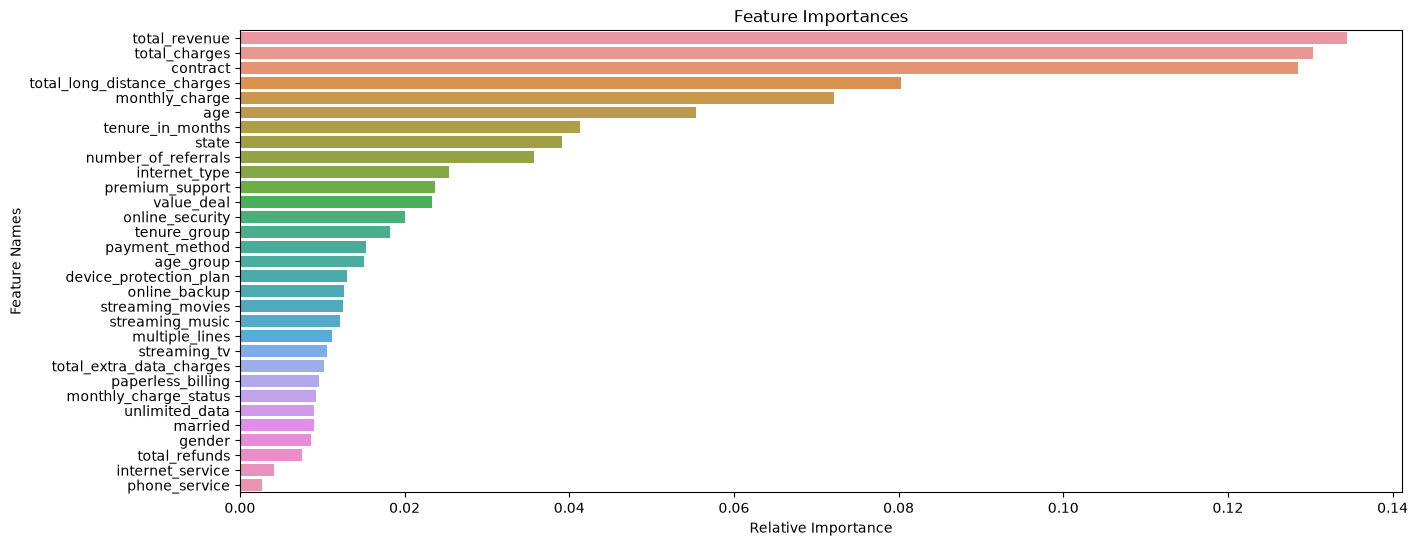

In [16]:
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=x.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()

## Predicting on New Data

### Extracting Data

In [17]:
sql_query = """
    select *
    from data_mart_customer.machine_learning_join
"""

In [ ]:
## without header: 
## c = conn.cursor() 
## df = pd.DataFrame(c.execute(sql_query))
new_df = pd.read_sql(sql_query, conn) ## with headers

In [ ]:
new_df.head()

### Transforming Data or Data Processing

Retaining the original dataframe to preserve unencoded columns

In [19]:
join_data = new_df.copy()

Retaining the customer_id column

In [20]:
customer_ids = new_df['customer_id']

Dropping columns that won't be used for prediction in the encoded dataframe

In [21]:
new_df = new_df.drop(['customer_id', 'customer_status', 'churn_status', 'churn_category', 'churn_reason'], axis=1)
new_df

,number_of_referrals,monthly_charge,monthly_charge_status,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,gender,married,...,multiple_lines,internet_service,internet_type,online_security,online_backup,device_protection_plan,premium_support,streaming_tv,streaming_movies,streaming_music
0,13,72.10,51-100,72.10,0.0,0,7.77,79.87,Female,No,...,Yes,Yes,Fiber Optic,No,No,No,No,No,No,No
1,9,19.85,<=20,57.20,0.0,0,9.36,66.56,Female,No,...,No,No,N/A,N/A,N/A,,N/A,N/A,N/A,N/A
2,14,44.30,21-50,44.30,0.0,0,42.95,87.25,Female,No,...,No,Yes,DSL,No,No,No,No,No,No,No
3,11,19.95,<=20,58.00,0.0,0,8.07,66.07,Female,Yes,...,No,No,N/A,N/A,N/A,,N/A,N/A,N/A,N/A
4,5,20.05,21-50,33.70,0.0,0,3.62,37.32,Male,Yes,...,No,No,N/A,N/A,N/A,,N/A,N/A,N/A,N/A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,14,19.20,<=20,37.20,0.0,0,14.06,51.26,Female,Yes,...,No,No,N/A,N/A,N/A,,N/A,N/A,N/A,N/A
407,7,44.00,21-50,44.00,0.0,0,26.15,70.15,Female,No,...,No,Yes,DSL,No,No,No,No,No,No,No
408,0,45.60,21-50,45.60,0.0,0,37.44,83.04,Male,No,...,No,Yes,DSL,No,No,No,No,No,No,No
409,7,-5.00,<=20,189.10,0.0,0,100.59,289.69,Female,Yes,...,No,Yes,DSL,No,No,No,No,No,Yes,Yes


Encoding categorical variables using the saved label encoders

In [ ]:
for column in new_df.select_dtypes(include=['object']).columns:
    new_df[column] = label_encoders[column].transform(new_df[column])

### Making Predictions

In [23]:
churn_predictions = rf_model.predict(new_df)

Adding predictions to the original dataframe

In [24]:
join_data['churn_status_predicted'] = churn_predictions

Filtering the dataframe to include only records predicted as "churned"

In [25]:
join_data = join_data[join_data['churn_status_predicted'] == 1]
join_data

,customer_id,number_of_referrals,monthly_charge,monthly_charge_status,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,gender,...,internet_service,internet_type,online_security,online_backup,device_protection_plan,premium_support,streaming_tv,streaming_movies,streaming_music,churn_status_predicted
0,93520-GUJ,13,72.10,51-100,72.1,0.0,0,7.77,79.87,Female,...,Yes,Fiber Optic,No,No,No,No,No,No,No,1
1,57256-BIH,9,19.85,<=20,57.2,0.0,0,9.36,66.56,Female,...,No,N/A,N/A,N/A,,N/A,N/A,N/A,N/A,1
2,72357-MAD,14,44.30,21-50,44.3,0.0,0,42.95,87.25,Female,...,Yes,DSL,No,No,No,No,No,No,No,1
3,66612-KAR,11,19.95,<=20,58.0,0.0,0,8.07,66.07,Female,...,No,N/A,N/A,N/A,,N/A,N/A,N/A,N/A,1
4,22119-WES,5,20.05,21-50,33.7,0.0,0,3.62,37.32,Male,...,No,N/A,N/A,N/A,,N/A,N/A,N/A,N/A,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,21065-HAR,5,20.30,21-50,20.3,0.0,0,10.84,31.14,Male,...,No,N/A,N/A,N/A,,N/A,N/A,N/A,N/A,1
406,31412-HAR,14,19.20,<=20,37.2,0.0,0,14.06,51.26,Female,...,No,N/A,N/A,N/A,,N/A,N/A,N/A,N/A,1
407,54997-UTT,7,44.00,21-50,44.0,0.0,0,26.15,70.15,Female,...,Yes,DSL,No,No,No,No,No,No,No,1
408,56728-RAJ,0,45.60,21-50,45.6,0.0,0,37.44,83.04,Male,...,Yes,DSL,No,No,No,No,No,No,No,1


Saving the results

In [ ]:
import socket
socket.gethostname()

In [ ]:
connection = sqlalchemy.create_engine(f'mssql+pyodbc://{socket.gethostname()}\\SQLEXPRESS/DataWarehouse?trusted_connection=yes, driver=ODBC Driver 18 for SQL Server & trust_server_certificate=true')

In [ ]:
join_data.to_sql('churn_prediction', con = connection, schema = 'data_mart_customer', if_exists = 'replace', index = False)